# Sales Data Analysis

## 1. Library Imports

In [74]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## 2. Data Loading

In [75]:
df = pd.read_csv("Nassau Candy Distributor.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## 3. Initial Data Overview

In [76]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10194
Columns : 18


In [77]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Row ID,10194.0,5097.500000,2942.898656,1.00,2549.25,5097.50,7645.75,10194.0
Customer ID,10194.0,134468.961154,20231.483007,100006.00,117212.00,133550.00,152051.00,192314.0
Sales,10194.0,13.908537,11.341020,1.25,7.20,10.80,18.00,260.0
Units,10194.0,3.791838,2.228317,1.00,2.00,3.00,5.00,14.0
Gross Profit,10194.0,9.166451,6.643740,0.25,4.90,7.47,12.25,130.0
Cost,10194.0,4.742087,5.061647,0.60,2.40,3.60,5.70,130.0


In [80]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [81]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Country/Region,0
City,0
State/Province,0
Postal Code,0


In [82]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Country/Region',
 'City',
 'State/Province',
 'Postal Code',
 'Division',
 'Region',
 'Product ID',
 'Product Name',
 'Sales',
 'Units',
 'Gross Profit',
 'Cost']

## 4. Feature Engineering and Data Type Conversion

In [83]:
df["Profit Per Unit"] = df["Gross Profit"] / df["Units"]

In [84]:
df["Gross Margin %"] = (df["Gross Profit"] / df["Sales"]) * 100

In [85]:
df["Revenue Contribution"] = (
    df["Sales"] / df["Sales"].sum()
) * 100

df["Profit Contribution"] = (
    df["Gross Profit"] / df["Gross Profit"].sum()
) * 100

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Profit Per Unit,Gross Margin %,Revenue Contribution,Profit Contribution
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2.11,64.923077,0.004584,0.004516
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2.45,65.333333,0.005290,0.005244
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2.49,71.346705,0.007384,0.007994
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2.50,69.444444,0.007617,0.008026
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2.45,65.333333,0.007935,0.007866


In [86]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Profit Per Unit,Gross Margin %,Revenue Contribution,Profit Contribution
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2.11,64.923077,0.004584,0.004516
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2.45,65.333333,0.005290,0.005244
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2.49,71.346705,0.007384,0.007994
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2.50,69.444444,0.007617,0.008026
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2.45,65.333333,0.007935,0.007866


## 5. Key Metrics Overview

In [87]:
print("Total Revenue :", round(df["Sales"].sum(),2))

print("Total Profit :", round(df["Gross Profit"].sum(),2))

print("Average Margin :", round(df["Gross Margin %"].mean(),2))

print("Products :", df["Product Name"].nunique())

print("Orders :", df["Order ID"].nunique())

print("Divisions :", df["Division"].nunique())

Total Revenue : 141783.63
Total Profit : 93442.8
Average Margin : 66.51
Products : 15
Orders : 8549
Divisions : 3


## 6. Pareto Analysis (80/20 Rule)

In [88]:
pareto = (
    df.groupby("Product Name")
      .agg({
          "Sales":"sum",
          "Gross Profit":"sum"
      })
      .reset_index()
)

pareto = pareto.sort_values(
    "Gross Profit",
    ascending=False
)

pareto["Cumulative Profit"] = pareto["Gross Profit"].cumsum()

pareto["Cumulative %"] = (
    pareto["Cumulative Profit"]
    / pareto["Gross Profit"].sum()
) * 100

pareto.head()

,Product Name,Sales,Gross Profit,Cumulative Profit,Cumulative %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,19357.50,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,37967.70,40.632023
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,55411.07,59.299454
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,72231.02,77.299717
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,88824.62,95.057747


In [89]:
fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=pareto["Product Name"],
        y=pareto["Gross Profit"],
        name="Gross Profit"
    )
)

fig.add_trace(
    go.Scatter(
        x=pareto["Product Name"],
        y=pareto["Cumulative %"],
        yaxis="y2",
        mode="lines",
        line=dict(color="red", width=3),
        name="Cumulative %"
    )
)

fig.update_layout(

title="Pareto Analysis (80/20 Rule)",

xaxis_title="Products",

yaxis_title="Gross Profit",

yaxis2=dict(
overlaying="y",
side="right",
title="Cumulative %",
range=[0,100]
),

template="plotly_white",
height=650

)

fig.show()

## 7. Risk Categorization

In [90]:
risk = df.copy()

# Calculate Gross Margin %
risk["Gross Margin %"] = (risk["Gross Profit"] / risk["Sales"]) * 100

risk["Risk"] = np.where(

risk["Gross Margin %"] < 20,

"High Risk",

np.where(

risk["Gross Margin %"] < 40,

"Medium Risk",

"Low Risk"

)

)

risk.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Profit Per Unit,Gross Margin %,Revenue Contribution,Profit Contribution,Risk
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,2.11,64.923077,0.004584,0.004516,Low Risk
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,2.45,65.333333,0.005290,0.005244,Low Risk
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,2.49,71.346705,0.007384,0.007994,Low Risk
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,2.50,69.444444,0.007617,0.008026,Low Risk
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,2.45,65.333333,0.007935,0.007866,Low Risk


In [91]:
fig = px.pie(

risk,

names="Risk",

title="Margin Risk Distribution",

color="Risk",

color_discrete_map={

"High Risk":"red",

"Medium Risk":"orange",

"Low Risk":"green"

}

)

fig.update_layout(template="plotly_white")

fig.show()

In [92]:
high_risk = risk[
    risk["Risk"]=="High Risk"
]

high_risk = high_risk[[
    "Product Name",
    "Division",
    "Sales",
    "Cost",
    "Gross Profit",
    "Gross Margin %"
]]

high_risk.head(20)

,Product Name,Division,Sales,Cost,Gross Profit,Gross Margin %
26,Kazookles,Other,9.75,9.0,0.75,7.692308
92,Kazookles,Other,13.00,12.0,1.00,7.692308
160,Kazookles,Other,19.50,18.0,1.50,7.692308
200,Kazookles,Other,9.75,9.0,0.75,7.692308
210,Kazookles,Other,13.00,12.0,1.00,7.692308
228,Kazookles,Other,9.75,9.0,0.75,7.692308
245,Kazookles,Other,22.75,21.0,1.75,7.692308
389,Kazookles,Other,26.00,24.0,2.00,7.692308
455,Kazookles,Other,16.25,15.0,1.25,7.692308
495,Kazookles,Other,9.75,9.0,0.75,7.692308


In [93]:
sales_by_risk = risk.groupby('Risk')['Sales'].sum().reset_index()

fig = px.bar(
    sales_by_risk,
    x='Risk',
    y='Sales',
    title='Total Sales by Risk Category',
    color='Risk',
    color_discrete_map={
        "High Risk": "red",
        "Medium Risk": "orange",
        "Low Risk": "green"
    }
)

fig.update_layout(template="plotly_white")
fig.show()

## 8. Product Profitability Analysis

In [94]:
ppu = (
    df.groupby("Product Name")["Profit Per Unit"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    ppu,
    x="Profit Per Unit",
    y="Product Name",
    orientation="h",
    color="Profit Per Unit",
    color_continuous_scale="Viridis",
    title="Top Products by Profit Per Unit"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [95]:
margin = (
    df.groupby("Product Name")["Gross Margin %"]
      .mean()
      .sort_values()
      .head(10)
      .reset_index()
)

fig = px.bar(
    margin,
    x="Gross Margin %",
    y="Product Name",
    orientation="h",
    color="Gross Margin %",
    color_continuous_scale="Reds",
    title="Lowest Margin Products"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [96]:
top_profit = (
    df.groupby("Product Name")["Gross Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_profit,
    x="Gross Profit",
    y="Product Name",
    orientation="h",
    color="Gross Profit",
    title="Top 10 Products by Gross Profit",
    color_continuous_scale="Greens"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [97]:
top_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

fig = px.bar(
    top_sales,
    x="Sales",
    y="Product Name",
    orientation="h",
    color="Sales",
    title="Top 10 Products by Revenue",
    color_continuous_scale="Blues"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

## 9. Sales and Profit Distributions

In [98]:
fig = px.scatter(
    df,
    x="Cost",
    y="Sales",
    size="Gross Profit",
    color="Division",
    hover_name="Product Name",
    title="Revenue vs Manufacturing Cost"
)

fig.update_layout(template="plotly_white")

fig.show()

In [99]:
fig = px.scatter(
    df,
    x="Cost",
    y="Gross Profit",
    color="Division",
    hover_name="Product Name",
    size="Sales",
    title="Profit vs Manufacturing Cost"
)

fig.update_layout(template="plotly_white")

fig.show()

In [100]:
fig = px.histogram(
    df,
    x="Cost",
    nbins=40,
    color_discrete_sequence=["#F59E0B"],
    title="Cost Distribution"
)

fig.update_layout(template="plotly_white")

fig.show()

In [101]:
fig = px.histogram(
    df,
    x="Gross Profit",
    nbins=40,
    color_discrete_sequence=["#10B981"],
    title="Gross Profit Distribution"
)

fig.update_layout(template="plotly_white")

fig.show()

In [102]:
fig = px.histogram(
    df,
    x="Sales",
    nbins=40,
    color_discrete_sequence=["#4F46E5"],
    title="Revenue Distribution"
)

fig.update_layout(template="plotly_white")

fig.show()

In [103]:
fig = px.box(
    df,
    y="Sales",
    color="Division",
    title="Revenue Distribution by Division"
)

fig.update_layout(template="plotly_white")

fig.show()

## 10. Correlation Analysis

In [104]:
numeric = df.select_dtypes(include=np.number)

numeric.corr()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost,Profit Per Unit,Gross Margin %,Revenue Contribution,Profit Contribution
Row ID,1.000000,-0.008749,0.005513,0.000502,0.008031,0.001812,0.023530,0.017730,0.005513,0.008031
Customer ID,-0.008749,1.000000,-0.005401,-0.011616,-0.005964,-0.004274,0.006425,0.012470,-0.005401,-0.005964
Sales,0.005513,-0.005401,1.000000,0.729347,0.976404,0.958986,0.573643,-0.111106,1.000000,0.976404
Units,0.000502,-0.011616,0.729347,1.000000,0.815820,0.563344,0.010298,-0.013689,0.729347,0.815820
Gross Profit,0.008031,-0.005964,0.976404,0.815820,1.000000,0.875144,0.509454,0.036781,0.976404,1.000000
Cost,0.001812,-0.004274,0.958986,0.563344,0.875144,1.000000,0.616602,-0.297219,0.958986,0.875144
Profit Per Unit,0.023530,0.006425,0.573643,0.010298,0.509454,0.616602,1.000000,0.119464,0.573643,0.509454
Gross Margin %,0.017730,0.012470,-0.111106,-0.013689,0.036781,-0.297219,0.119464,1.000000,-0.111106,0.036781
Revenue Contribution,0.005513,-0.005401,1.000000,0.729347,0.976404,0.958986,0.573643,-0.111106,1.000000,0.976404
Profit Contribution,0.008031,-0.005964,0.976404,0.815820,1.000000,0.875144,0.509454,0.036781,0.976404,1.000000


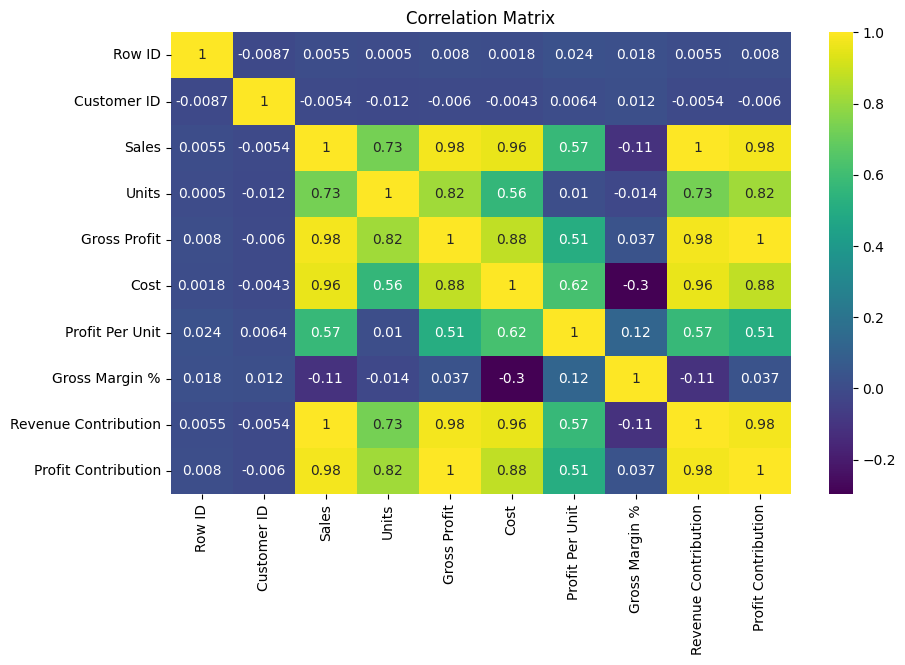

In [105]:
plt.figure(figsize=(10,6))

numeric = df.select_dtypes(include=np.number)
sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="viridis"
)

plt.title("Correlation Matrix")

plt.show()

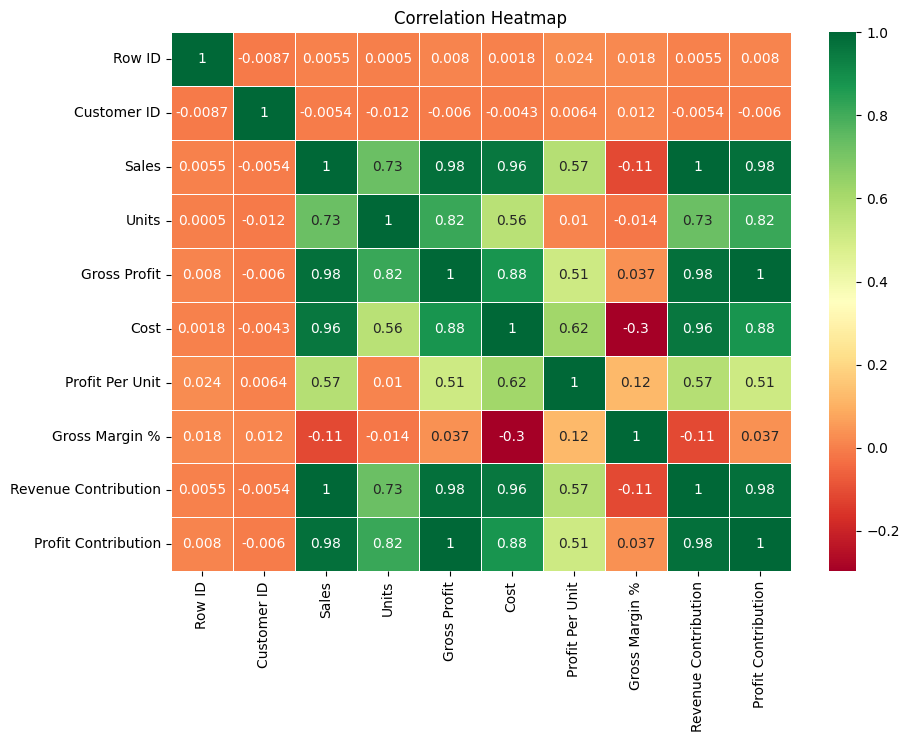

In [106]:
plt.figure(figsize=(10,7))

sns.heatmap(

df.select_dtypes(include=np.number).corr(),

annot=True,

cmap="RdYlGn",

linewidths=0.5

)

plt.title("Correlation Heatmap")

plt.show()

## 11. Time Series Analysis (Monthly Sales and Profit)

In [107]:
monthly = (
    df.groupby(df["Order Date"].dt.to_period("M"))
      .agg({
          "Sales":"sum",
          "Gross Profit":"sum"
      })
      .reset_index()
)

monthly["Order Date"] = monthly["Order Date"].astype(str)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=monthly["Order Date"],
        y=monthly["Sales"],
        mode="lines+markers",
        name="Revenue"
    )
)

fig.add_trace(
    go.Scatter(
        x=monthly["Order Date"],
        y=monthly["Gross Profit"],
        mode="lines+markers",
        name="Gross Profit"
    )
)

fig.update_layout(
    title="Monthly Revenue vs Gross Profit",
    template="plotly_white",
    height=550
)

fig.show()

## 12. Sales by Shipping Mode

In [108]:
ship = (
    df.groupby("Ship Mode")
      .agg({
          "Sales":"sum",
          "Gross Profit":"sum"
      })
      .reset_index()
)

fig = px.bar(
    ship,
    x="Ship Mode",
    y="Sales",
    color="Gross Profit",
    title="Sales by Shipping Mode"
)

fig.update_layout(template="plotly_white")

fig.show()

## 13. Geographic Sales Analysis

In [109]:
state = (
    df.groupby("State/Province")
      .agg({
          "Sales":"sum",
          "Gross Profit":"sum"
      })
      .reset_index()
)

state = state.sort_values(
    "Sales",
    ascending=False
).head(15)

fig = px.bar(
    state,
    x="Sales",
    y="State/Province",
    orientation="h",
    color="Gross Profit",
    title="Top 15 States by Revenue"
)

fig.update_layout(
    template="plotly_white",
    yaxis=dict(categoryorder="total ascending")
)

fig.show()

In [110]:
region_summary = (
    df.groupby("Region")
      .agg({
          "Sales":"sum",
          "Gross Profit":"sum"
      })
      .reset_index()
)

region_summary.head()

,Region,Sales,Gross Profit
0,Atlantic,41197.24,26973.70
1,Gulf,22247.26,14700.67
2,Interior,32037.60,21282.49
3,Pacific,46301.53,30485.94


In [111]:
fig = px.bar(
    region_summary,
    x="Region",
    y="Gross Profit",
    color="Region",
    text_auto=".2s",
    title="Gross Profit by Region"
)

fig.update_layout(template="plotly_white")

fig.show()

In [112]:
fig = px.pie(
    region_summary,
    names="Region",
    values="Sales",
    hole=0.45,
    title="Revenue Distribution by Region"
)

fig.update_layout(template="plotly_white")

fig.show()

## 14. Divisional Sales Analysis

In [113]:
division_summary = (
    df.groupby("Division")
      .agg({
          "Sales":"sum",
          "Gross Profit":"sum",
          "Cost":"sum",
          "Units":"sum"
      })
      .reset_index()
)

division_summary

,Division,Sales,Gross Profit,Cost,Units
0,Chocolate,131692.90,88824.62,42868.28,37275
1,Other,9663.25,4333.45,5329.80,1242
2,Sugar,427.48,284.73,142.75,137


In [114]:
fig = px.treemap(
    division_summary,
    path=["Division"],
    values="Sales",
    color="Gross Profit",
    color_continuous_scale="Viridis",
    title="Revenue Distribution by Division"
)

fig.show()

In [115]:
division_summary["Gross Margin %"] = (division_summary["Gross Profit"] / division_summary["Sales"]) * 100

fig = px.bar(
    division_summary,
    x="Division",
    y="Gross Margin %",
    color="Division",
    title="Average Gross Margin (%) by Division"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

In [116]:
fig = px.bar(
    division_summary,
    x="Division",
    y="Gross Profit",
    color="Division",
    text_auto=".2s",
    title="Gross Profit by Division"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

In [117]:
fig = px.bar(
    division_summary,
    x="Division",
    y="Sales",
    color="Division",
    text_auto=".2s",
    title="Revenue by Division"
)

fig.update_layout(
    template="plotly_white",
    height=500
)

fig.show()

## 15. Gross Margin % vs Sales Analysis

In [118]:
fig = px.scatter(
    df,
    x="Sales",
    y="Gross Margin %",
    color="Division",
    size="Gross Profit",
    hover_name="Product Name",
    title="Gross Margin % vs Sales"
)

fig.update_layout(template="plotly_white")

fig.show()

## 16. High-Performing Products Analysis

In [119]:
# Calculate the 75th percentile for Sales and Gross Margin %
sales_75th_percentile = df['Sales'].quantile(0.75)
gross_margin_75th_percentile = df['Gross Margin %'].quantile(0.75)

# Filter for high-performing products
high_performing_products = df[
    (df['Sales'] >= sales_75th_percentile) &
    (df['Gross Margin %'] >= gross_margin_75th_percentile)
]

# Group by product name and sum relevant metrics
high_performing_summary = high_performing_products.groupby('Product Name').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Gross Margin %': 'mean',
    'Units': 'sum'
}).reset_index()

# Sort by Sales in descending order and display the top 10
top_10_high_performing = high_performing_summary.sort_values(by='Sales', ascending=False).head(10)
display(top_10_high_performing)

,Product Name,Sales,Gross Profit,Gross Margin %,Units
3,Wonka Bar -Scrumdiddlyumptious,14832.00,10300.00,69.444444,4120
2,Wonka Bar - Nutty Crunch Surprise,8547.01,6098.01,71.346705,2449
0,Everlasting Gobstopper,130.00,104.00,80.000000,13
1,Hair Toffee,67.50,52.50,77.777778,15


In [16]:
fig = px.scatter(

df,

x="Cost",

y="Gross Profit",

size="Sales",

color="Division",

hover_name="Product Name",

title="Profit vs Manufacturing Cost"

)

fig.update_layout(template="plotly_white")

fig.show()

In [23]:
fig = px.sunburst(
    df,
    path=["Division", "Region"],
    values="Sales",
    color="Gross Profit",
    title="Division → Region Sales Distribution"
)

fig.show()